In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_curve, roc_auc_score
from xgboost import XGBClassifier

url = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"
df = pd.read_csv(url)


print("--- Primeiras 5 linhas do Dataset ---")
display(df.head())


print("\n--- Proporção das Classes ---")
print(df["Class"].value_counts(normalize=True))

--- Primeiras 5 linhas do Dataset ---


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0



--- Proporção das Classes ---
Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64


In [ ]:
df["Amount_log"] = np.log1p(df["Amount"])

scaler = StandardScaler()
df["Amount_scaled"] = scaler.fit_transform(df[["Amount"]])


print("--- Dataset com as novas Features ---")
display(df[["Amount", "Amount_log", "Amount_scaled"]].head())

--- Dataset com as novas Features ---


,Amount,Amount_log,Amount_scaled
0,149.62,5.014760,0.244964
1,2.69,1.305626,-0.342475
2,378.66,5.939276,1.160686
3,123.50,4.824306,0.140534
4,69.99,4.262539,-0.073403


In [ ]:
X = df.drop("Class", axis=1)
y = df["Class"]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.3, random_state=42
)

print(f"Tamanho do Treino: {X_train.shape[0]} linhas")
print(f"Tamanho do Teste:  {X_test.shape[0]} linhas")

Tamanho do Treino: 199364 linhas
Tamanho do Teste:  85443 linhas


In [ ]:
pipeline_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

pipeline_lr.fit(X_train, y_train)


y_pred_lr = pipeline_lr.predict(X_test)

print("--- Relatório: Regressão Logística (Threshold 0.5) ---")
print(classification_report(y_test, y_pred_lr))

--- Relatório: Regressão Logística (Threshold 0.5) ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.86      0.61      0.72       148

    accuracy                           1.00     85443
   macro avg       0.93      0.81      0.86     85443
weighted avg       1.00      1.00      1.00     85443



In [ ]:
y_probs_lr = pipeline_lr.predict_proba(X_test)[:, 1]


threshold = 0.3
y_pred_custom = (y_probs_lr > threshold).astype(int)

print(f"--- Relatório: Regressão Logística (Threshold {threshold}) ---")
print(classification_report(y_test, y_pred_custom))

--- Relatório: Regressão Logística (Threshold 0.3) ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.79      0.66      0.72       148

    accuracy                           1.00     85443
   macro avg       0.89      0.83      0.86     85443
weighted avg       1.00      1.00      1.00     85443



In [ ]:
rf = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("--- Relatório: Random Forest Balanceado ---")
print(classification_report(y_test, y_pred_rf))

--- Relatório: Random Forest Balanceado ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.84      0.76      0.79       148

    accuracy                           1.00     85443
   macro avg       0.92      0.88      0.90     85443
weighted avg       1.00      1.00      1.00     85443



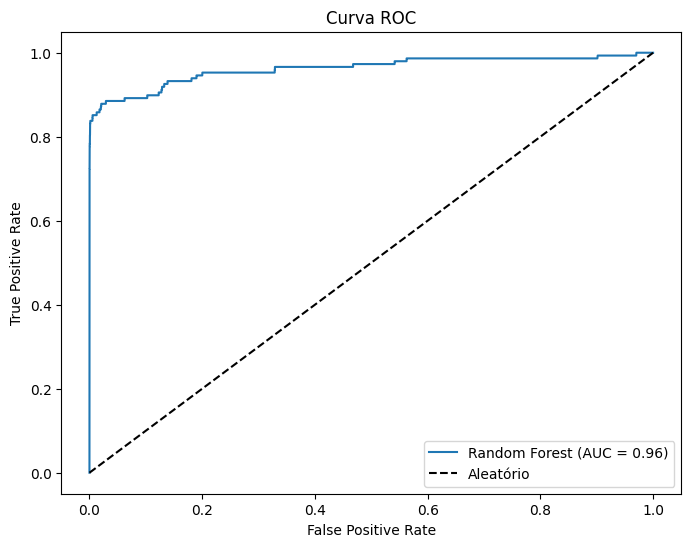

AUC: 0.9620539922653177


In [ ]:
y_probs_rf = rf.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_probs_rf)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"Random Forest (AUC = {roc_auc_score(y_test, y_probs_rf):.2f})")
plt.plot([0, 1], [0, 1], 'k--', label="Aleatório")
plt.title("Curva ROC")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

print("AUC:", roc_auc_score(y_test, y_probs_rf))

In [ ]:
xgb = XGBClassifier(
    scale_pos_weight=10,
    eval_metric="logloss",
    random_state=42
)

xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

print("--- Relatório: XGBoost ---")
print(classification_report(y_test, y_pred_xgb))

--- Relatório: XGBoost ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.94      0.78      0.85       148

    accuracy                           1.00     85443
   macro avg       0.97      0.89      0.93     85443
weighted avg       1.00      1.00      1.00     85443



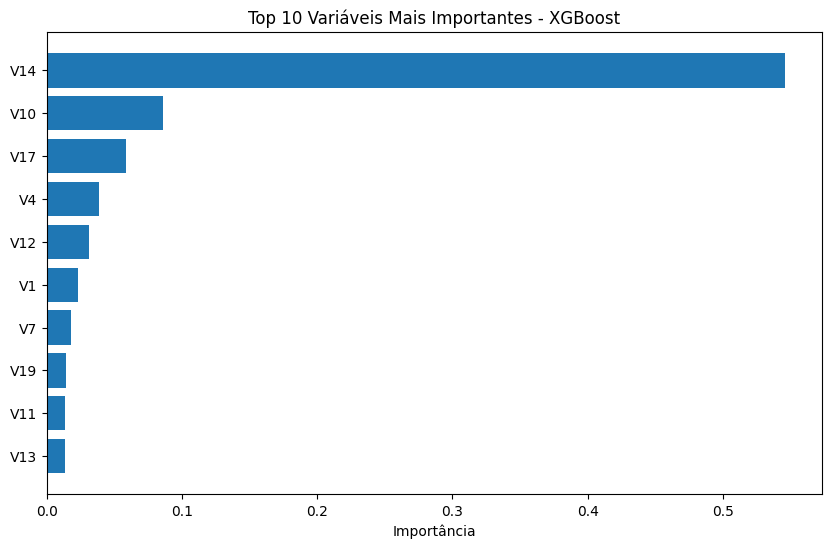

In [ ]:

importancias = xgb.feature_importances_
importancias_df = pd.DataFrame({
    'Variavel': X_train.columns,
    'Importancia': importancias
}).sort_values(by='Importancia', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(importancias_df['Variavel'][:10], importancias_df['Importancia'][:10])
plt.xlabel('Importância')
plt.title('Top 10 Variáveis Mais Importantes - XGBoost')
plt.gca().invert_yaxis()
plt.show()

In [ ]:
param_grid = {
    "max_depth": [3, 5],
    "n_estimators": [50, 100]
}

grid = GridSearchCV(
    XGBClassifier(eval_metric="logloss", random_state=42),
    param_grid,
    scoring="recall",
    cv=3,
    n_jobs=-1
)


print("Treinando GridSearch... (isso pode levar alguns minutos)")
grid.fit(X_train, y_train)

print("\nMelhores parâmetros encontrados:", grid.best_params_)

# Avaliando o melhor modelo
y_pred_grid = grid.best_estimator_.predict(X_test)
print("\n--- Relatório: XGBoost Otimizado ---")
print(classification_report(y_test, y_pred_grid))

Treinando GridSearch... (isso pode levar alguns minutos)

Melhores parâmetros encontrados: {'max_depth': 5, 'n_estimators': 100}

--- Relatório: XGBoost Otimizado ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.84      0.72      0.78       148

    accuracy                           1.00     85443
   macro avg       0.92      0.86      0.89     85443
weighted avg       1.00      1.00      1.00     85443



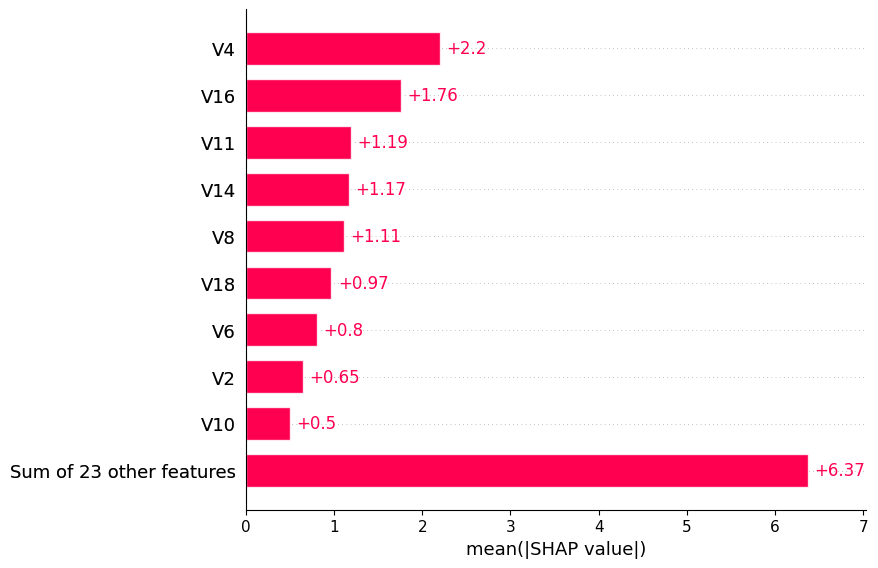

In [ ]:
explainer = shap.Explainer(grid.best_estimator_)

# Calculando os valores SHAP para uma amostra (100 transações)
shap_values = explainer(X_test[:100])

shap.plots.bar(shap_values)